In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv


Dataset loaded successfully! Shape: (545, 13)

Model training complete.

--- Model Evaluation ---
R² Score: 0.5464
RMSE: $1,514,173.55


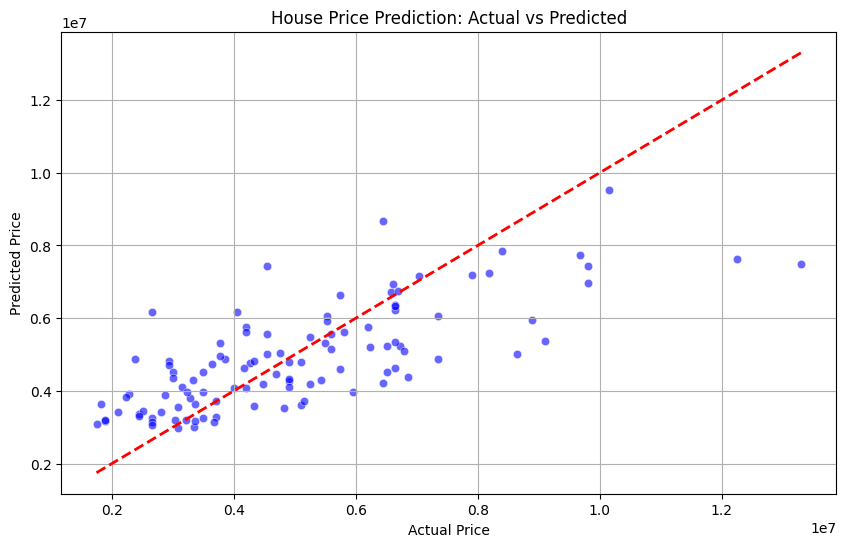

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# --- Step 1: Load the Correct Dataset Path ---
file_path = '/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv'
df = pd.read_csv(file_path)
print(f"Dataset loaded successfully! Shape: {df.shape}\n")

# --- Step 2: Identify Target and Features ---
# Automatically handle case-sensitivity for the target column ('price' or 'Price')
target_col = 'price' if 'price' in df.columns else 'Price'

# Select only numerical columns for basic Linear Regression
numerical_df = df.select_dtypes(include=[np.number])

X = numerical_df.drop(columns=[target_col], errors='ignore')
y = numerical_df[target_col]

# Handle any potential missing values
X = X.fillna(X.median())

# Split into train and test sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 3: Train Linear Regression Model ---
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training complete.")

# --- Step 4: Predict House Prices ---
y_pred = model.predict(X_test)

# --- Step 5: Evaluate R² Score ---
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Model Evaluation ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: ${rmse:,.2f}")

# --- Step 6: Plot Predicted vs Actual Values ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('House Price Prediction: Actual vs Predicted')
plt.grid(True)
plt.show()